In [1]:
#### -------------------------------------------------------------------------------------------------------------------------------------------------------
#### author: Ranjan Barman, date: May 30, 2025 (modified for immune only)
#### Predict individual BRCA Subtype Status using non-zero coefficients from inner_cv HoverNet predicted immune-only NPIFs
#### Also save the models for external validation
#### -------------------------------------------------------------------------------------------------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, roc_auc_score, roc_curve, auc
import random
import joblib

# Set working directory
_wpath_ = "/data/Lab_ruppin/Ranjan/HnE/"
os.chdir(_wpath_)
print(f"working directory = {_wpath_}\n")



working directory = /data/Lab_ruppin/Ranjan/HnE/



In [2]:
# Define dataset and file paths
dataset_name = "TCGA_BRCA_FFPE"
outcome_names = ["HER2_Status", "PR_Status", "ER_Status"]

# File: immune-only NPIFs mapped to subtypes
hovernet_NPIFs_with_BRCA_status_file = f"{dataset_name}/outputs/HoverNet/Subtypes/HoverNet_ImmuneOnly_NPIFs_Mapped_BRCA_Status_Top25P_Tiles.csv"

# Output path to save results and plots
out_path = f"{dataset_name}/outputs/HoverNet/Subtypes/Prediction_results_HoverNet_ImmuneOnly_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/"
model_save_path = os.path.join(out_path, "saved_models/")
os.makedirs(model_save_path, exist_ok=True)

# Load immune-only NPIFs with BRCA subtypes
hovernet_NPIFs_with_BRCA_status_full = pd.read_csv(hovernet_NPIFs_with_BRCA_status_file)
hovernet_NPIFs_with_BRCA_status_full.columns = hovernet_NPIFs_with_BRCA_status_full.columns.str.strip()
hovernet_NPIFs_with_BRCA_status_full.rename(columns={"sampleID": "sample_id"}, inplace=True)

# File for sample list used in TCGA BRCA subtype prediction (n=556)
TCGA_BRCA_Subtypes_556_file = f"{dataset_name}/outputs/HoverNet/Subtypes/outputs_biomarker_status_prediction_results_All_HoverNet_NPIFs/combined_class_predictions_all_features_for_subtypes.csv"
TCGA_BRCA_Subtypes_556 = pd.read_csv(TCGA_BRCA_Subtypes_556_file)

# Filter to those 556 samples
sample_list_556 = TCGA_BRCA_Subtypes_556['sample_id'].reset_index(drop=True)
hovernet_NPIFs_with_BRCA_status_full = hovernet_NPIFs_with_BRCA_status_full[
    hovernet_NPIFs_with_BRCA_status_full['sample_id'].isin(sample_list_556)
].copy()

# Define full and filtered patient lists
patient_list = hovernet_NPIFs_with_BRCA_status_full['sample_id'].reset_index(drop=True)

# Keep only Positive/Negative outcome samples
data_filtered = hovernet_NPIFs_with_BRCA_status_full[
    hovernet_NPIFs_with_BRCA_status_full[outcome_names].isin(["Positive", "Negative"]).all(axis=1)
]

filtered_patient_list = data_filtered['sample_id'].reset_index(drop=True)

# Define NPIF features (assumes all feature columns start from 5th column onward)
X = data_filtered.iloc[:, 6:].copy()

# Show dataframes for verification
hovernet_NPIFs_with_BRCA_status_full
filtered_patient_list
data_filtered
X


,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
0,6.025637,3.434522,2.396370,9.690980,0.672433,0.787732,2.533152,0.820652,0.491219,2.202946,0.144434,0.081289
1,5.773401,3.285018,2.407675,9.370934,0.636962,0.812644,1.887750,0.648373,0.388339,1.654835,0.146252,0.062008
2,6.915839,3.528585,2.608073,10.090879,0.633787,0.818044,3.208622,0.848080,0.600537,2.346727,0.144584,0.061430
3,4.510537,2.918297,2.142227,8.268236,0.635349,0.820480,1.341168,0.538948,0.309527,1.348932,0.148232,0.064460
4,6.190965,3.382322,2.485305,9.666073,0.631440,0.816383,2.318742,0.737734,0.424438,1.889158,0.149531,0.065511
...,...,...,...,...,...,...,...,...,...,...,...,...
710,5.482632,3.139946,2.378415,9.069134,0.602785,0.821542,1.994682,0.658274,0.393364,1.706653,0.155256,0.063612
711,5.766904,3.212860,2.444914,9.314245,0.604742,0.822665,1.828997,0.612447,0.366758,1.568889,0.147191,0.059226
712,5.118412,3.095301,2.275220,8.814928,0.632678,0.811471,1.770513,0.619668,0.387539,1.592570,0.151494,0.063336
713,5.226732,3.087368,2.333896,8.926776,0.602812,0.817199,1.625512,0.638581,0.327071,1.603382,0.152839,0.073113


In [3]:
# Initialize a DataFrame to store the combined results
combined_results_df = pd.DataFrame({'sample_id': filtered_patient_list.values})
combined_results_df.set_index('sample_id', inplace=True)

# Define hyperparameter grid for Logistic Regression with L2 penalty (Ridge)
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
}

# Define cross-validation parameters
n_folds = 5
seed = 20852
shuffle = True

# Define subtype names
subtype_names_3 = ['HER2_Positive', 'HR_Positive', 'TNBC_3']
subtype_names_4 = ['HR+', 'TNBC_4', 'TPBC', 'HER2+']
all_subtype_names = subtype_names_3 + subtype_names_4

# Step 1: Define true subtypes from HER2/ER/PR status
def define_true_subtypes(df):
    HER2 = df['HER2_Status'] == 'Positive'
    ER = df['ER_Status'] == 'Positive'
    PR = df['PR_Status'] == 'Positive'

    df['HER2_Positive'] = HER2.astype(int)
    df['HR_Positive'] = ((ER | PR) & ~HER2).astype(int)
    df['TNBC_3'] = (~HER2 & ~ER & ~PR).astype(int)

    df['HR+'] = (ER & ~HER2).astype(int)
    df['TNBC_4'] = (~ER & ~HER2).astype(int)
    df['TPBC'] = (ER & HER2).astype(int)
    df['HER2+'] = (~ER & HER2).astype(int)

    return df

# Apply subtype definition
data_filtered = define_true_subtypes(data_filtered)

# Step 2: Define NPIF features only (exclude all label-related columns)
columns_to_exclude = ['sample_id', 'HER2_Status', 'PR_Status', 'ER_Status', 'Total_Tiles', 'Filtered_Tiles',
                      'HER2_Positive', 'HR_Positive', 'TNBC_3', 'HR+',
                      'TNBC_4', 'TPBC', 'HER2+']
feature_columns = [col for col in data_filtered.columns if col not in columns_to_exclude]
X = data_filtered[feature_columns].copy()

data_filtered
# feature_columns
# X

,sample_id,HER2_Status,PR_Status,ER_Status,Total_Tiles,Filtered_Tiles,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,...,Std Perimeter,Std Eccentricity,Std Circularity,HER2_Positive,HR_Positive,TNBC_3,HR+,TNBC_4,TPBC,HER2+
0,TCGA-A1-A0SB,Negative,Negative,Positive,1179,329,6.025637,3.434522,2.396370,9.690980,...,2.202946,0.144434,0.081289,0,1,0,1,0,0,0
1,TCGA-A1-A0SD,Negative,Positive,Positive,1003,264,5.773401,3.285018,2.407675,9.370934,...,1.654835,0.146252,0.062008,0,1,0,1,0,0,0
2,TCGA-A1-A0SE,Negative,Positive,Positive,4098,1053,6.915839,3.528585,2.608073,10.090879,...,2.346727,0.144584,0.061430,0,1,0,1,0,0,0
3,TCGA-A1-A0SF,Negative,Positive,Positive,1752,457,4.510537,2.918297,2.142227,8.268236,...,1.348932,0.148232,0.064460,0,1,0,1,0,0,0
4,TCGA-A1-A0SH,Negative,Positive,Negative,1618,473,6.190965,3.382322,2.485305,9.666073,...,1.889158,0.149531,0.065511,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
710,TCGA-EW-A1PB,Negative,Negative,Negative,3389,939,5.482632,3.139946,2.378415,9.069134,...,1.706653,0.155256,0.063612,0,0,1,0,1,0,0
711,TCGA-EW-A1PD,Positive,Positive,Positive,2034,568,5.766904,3.212860,2.444914,9.314245,...,1.568889,0.147191,0.059226,1,0,0,0,0,1,0
712,TCGA-EW-A1PE,Negative,Positive,Positive,2662,753,5.118412,3.095301,2.275220,8.814928,...,1.592570,0.151494,0.063336,0,1,0,1,0,0,0
713,TCGA-EW-A1PF,Negative,Positive,Positive,1331,340,5.226732,3.087368,2.333896,8.926776,...,1.603382,0.152839,0.073113,0,1,0,1,0,0,0


In [4]:
# Initialize result storage
results = {}
mean_f1_scores = []

# Loop through each subtype
for subtype in all_subtype_names:
    print(f"\nProcessing subtype: {subtype}")
    
    y = data_filtered[subtype]
    y_encoded = y.copy()

    outer_results = []
    y_true_all_folds = []
    predictions = []
    f1_scores = []

    # Track coefficients for all features across folds
    all_features = X.columns.tolist()
    coeff_tracker = {feat: [] for feat in all_features}  # values per fold, zero if not selected

    outer_cv = StratifiedKFold(n_splits=n_folds, shuffle=shuffle, random_state=seed)
    fold_idx = 1

    for train_idx, test_idx in outer_cv.split(X, y_encoded):
        print(f"\nOuter Fold {fold_idx}/{n_folds}")
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_encoded.iloc[train_idx], y_encoded.iloc[test_idx]
        patient_test_ids = filtered_patient_list.iloc[test_idx]

        # Print class balance
        print("Train class dist:", y_train.value_counts().to_dict())
        print("Test class dist :", y_test.value_counts().to_dict())

        inner_cv = StratifiedKFold(n_splits=n_folds, shuffle=shuffle, random_state=seed)
        
        pipeline = Pipeline([
            ('scaler', MinMaxScaler()),
            ('classifier', LogisticRegression(penalty='l1', solver='saga',
                                              class_weight='balanced', max_iter=10000))
        ])
        
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='roc_auc',
            n_jobs=-1
        )
        
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        print(f"Best parameters: {best_params}")
        
        # Save model
        model_filename = os.path.join(model_save_path, f"{subtype}_model_fold_{fold_idx}.joblib")
        joblib.dump(best_model, model_filename)
        print(f"Saved model with scaler: {model_filename}")

        # Extract coefficients
        coef = best_model.named_steps['classifier'].coef_.flatten()
        for feat, c in zip(all_features, coef):
            coeff_tracker[feat].append(c)  # may be zero

        # Predict
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        predictions.append(y_pred_proba)
        y_true_all_folds.extend(y_test)

        # Save predictions to results DataFrame
        combined_results_df.loc[patient_test_ids.values, f'true_label_{subtype}'] = y_test.values
        combined_results_df.loc[patient_test_ids.values, f'predicted_probability_{subtype}'] = y_pred_proba

        # Evaluate
        f1 = f1_score(y_test, (y_pred_proba >= 0.5).astype(int))
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        f1_scores.append(f1)

        print(f"F1-score: {f1:.4f}")
        print(f"ROC AUC : {roc_auc:.4f}")

        outer_results.append({
            'fold': fold_idx,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'best_params': best_params
        })

        fold_idx += 1

    # Save results
    mean_f1_score = np.mean(f1_scores)
    print(f"Mean F1-score for {subtype}: {mean_f1_score:.4f}")

    results[subtype] = {
        'outer_results': outer_results,
        'mean_f1_score': mean_f1_score,
        'best_params': best_params
    }
    mean_f1_scores.append(mean_f1_score)

    # Fill missing folds with 0s
    for feat in coeff_tracker:
        if len(coeff_tracker[feat]) < n_folds:
            coeff_tracker[feat] += [0.0] * (n_folds - len(coeff_tracker[feat]))
    
    # Convert to DataFrame with fold-wise rows and features as columns
    fold_coefficients_df = pd.DataFrame(coeff_tracker)
    fold_coefficients_df.index.name = 'fold'
    fold_coefficients_df.index = [f'Fold_{i+1}' for i in range(n_folds)]
    
    # Save all coefficients (including zeros) fold-wise
    coeff_output_file = os.path.join(out_path, f"{subtype}_foldwise_coefficients.csv")
    fold_coefficients_df.to_csv(coeff_output_file)
    print(f"Saved fold-wise coefficients (including zeros) for {subtype} to: {coeff_output_file}")




Processing subtype: HER2_Positive

Outer Fold 1/5
Train class dist: {0: 378, 1: 66}
Test class dist : {0: 95, 1: 17}
Best parameters: {'classifier__C': 100}
Saved model with scaler: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_HoverNet_ImmuneOnly_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/saved_models/HER2_Positive_model_fold_1.joblib
F1-score: 0.3429
ROC AUC : 0.6551

Outer Fold 2/5
Train class dist: {0: 378, 1: 67}
Test class dist : {0: 95, 1: 16}
Best parameters: {'classifier__C': 100}
Saved model with scaler: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_HoverNet_ImmuneOnly_All_HoverNet_NPIFs_Filtered_Tiles_Top25Q_Binary_Subtypes/saved_models/HER2_Positive_model_fold_2.joblib
F1-score: 0.3462
ROC AUC : 0.6658

Outer Fold 3/5
Train class dist: {0: 378, 1: 67}
Test class dist : {0: 95, 1: 16}
Best parameters: {'classifier__C': 100}
Saved model with scaler: TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_HoverNet_ImmuneOnly_All_H

In [5]:
# Save combined prediction outputs
combined_results_df.to_csv(os.path.join(out_path, 'combined_class_predictions_all_subtypes_binary.csv'), index=True)
combined_results_df

,true_label_HER2_Positive,predicted_probability_HER2_Positive,true_label_HR_Positive,predicted_probability_HR_Positive,true_label_TNBC_3,predicted_probability_TNBC_3,true_label_HR+,predicted_probability_HR+,true_label_TNBC_4,predicted_probability_TNBC_4,true_label_TPBC,predicted_probability_TPBC,true_label_HER2+,predicted_probability_HER2+
sample_id,,,,,,,,,,,,,,
TCGA-A1-A0SB,0.0,0.128409,1.0,0.832508,0.0,0.230537,1.0,0.790677,0.0,0.220187,0.0,0.172949,0.0,0.412411
TCGA-A1-A0SD,0.0,0.295102,1.0,0.784223,0.0,0.218486,1.0,0.809059,0.0,0.217050,0.0,0.311780,0.0,0.411859
TCGA-A1-A0SE,0.0,0.055694,1.0,0.758417,0.0,0.480964,1.0,0.716189,0.0,0.323455,0.0,0.119506,0.0,0.302712
TCGA-A1-A0SF,0.0,0.640044,1.0,0.638425,0.0,0.262865,1.0,0.567750,0.0,0.241640,0.0,0.658890,0.0,0.551597
TCGA-A1-A0SH,0.0,0.343587,1.0,0.602492,0.0,0.348743,0.0,0.662141,1.0,0.366582,0.0,0.425033,0.0,0.370942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-EW-A1PB,0.0,0.420005,0.0,0.591059,1.0,0.526546,0.0,0.551823,1.0,0.569811,0.0,0.330928,0.0,0.472839
TCGA-EW-A1PD,1.0,0.389720,0.0,0.539076,0.0,0.526476,0.0,0.533862,0.0,0.528525,1.0,0.233793,0.0,0.412373
TCGA-EW-A1PE,0.0,0.380302,1.0,0.757872,0.0,0.199003,1.0,0.773634,0.0,0.329412,0.0,0.502933,0.0,0.488764


In [6]:
# Mapping for 3-subtype ROC plotting
subtypes_3 = {
    'HER2_Positive': ('true_label_HER2_Positive', 'predicted_probability_HER2_Positive'),
    'HR_Positive': ('true_label_HR_Positive', 'predicted_probability_HR_Positive'),
    'TNBC_3': ('true_label_TNBC_3', 'predicted_probability_TNBC_3')
}

# Mapping for 4-subtype ROC plotting
subtypes_4 = {
    'HR+': ('true_label_HR+', 'predicted_probability_HR+'),
    'TNBC_4': ('true_label_TNBC_4', 'predicted_probability_TNBC_4'),
    'TPBC': ('true_label_TPBC', 'predicted_probability_TPBC'),
    'HER2+': ('true_label_HER2+', 'predicted_probability_HER2+')
}


In [7]:
colors = {
    'HER2_Positive': 'darkorange',
    'HR_Positive': 'blue',
    'TNBC_3': 'green',
    'HR+': 'blue',
    'TNBC_4': 'green',
    'TPBC': 'tomato',
    'HER2+': 'darkorange'
}
def plot_combined_roc_curves(df, subtypes, title, filename):
    plt.figure(figsize=(10, 8))
    total_samples = len(df)

    for subtype, (true_label_col, pred_prob_col) in subtypes.items():
        if subtype in ['TNBC_3', 'TNBC_4']:
            if 'TNBC' in colors:  # Avoid duplicated legend for TNBC
                continue
            label = 'TNBC'
        elif subtype == 'HER2_Positive':
            label = 'HER2+'
        elif subtype == 'HR_Positive':
            label = 'HR+'
        else:
            label = subtype

        # Filter valid entries
        valid_indices = (~df[true_label_col].isna()) & (~df[pred_prob_col].isna())
        true_labels = df[true_label_col][valid_indices]
        predicted_probs = df[pred_prob_col][valid_indices]

        # Compute ROC and AUC
        fpr, tpr, _ = roc_curve(true_labels, predicted_probs)
        roc_auc = auc(fpr, tpr)

        # Plot
        plt.plot(fpr, tpr, color=colors[subtype], lw=2,
                 label=f'{label} (AUC = {roc_auc:.2f}, n = {true_labels.sum():.0f})')

    # Reference diagonal
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=18)
    plt.ylabel('True Positive Rate', fontsize=18)
    plt.title(title, fontsize=18)
    plt.legend(loc="lower right", fontsize=18)
    plt.grid(True)

    # Save and show
    plt.savefig(os.path.join(out_path, filename), bbox_inches='tight')
    plt.show()


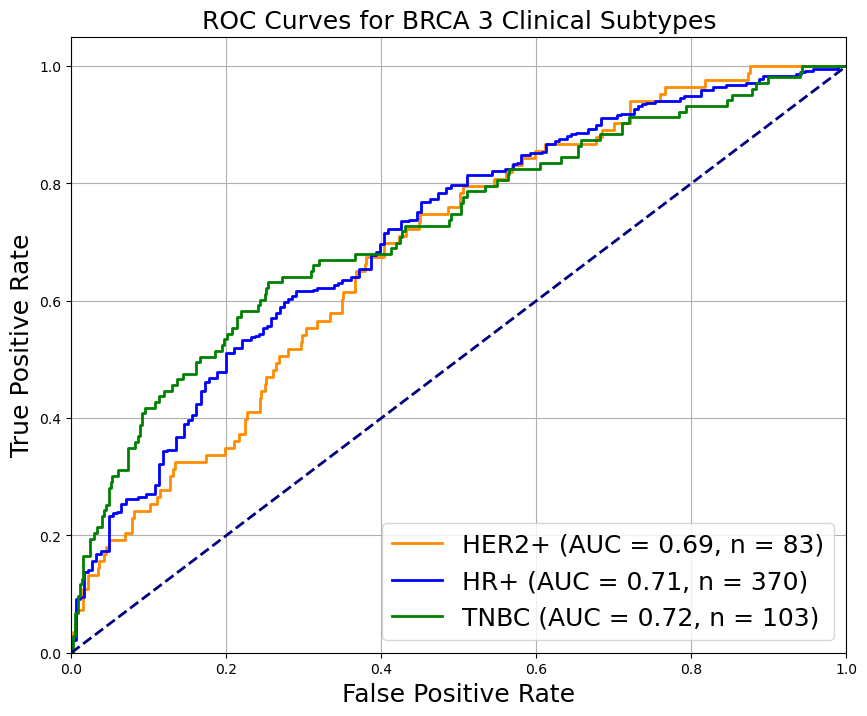

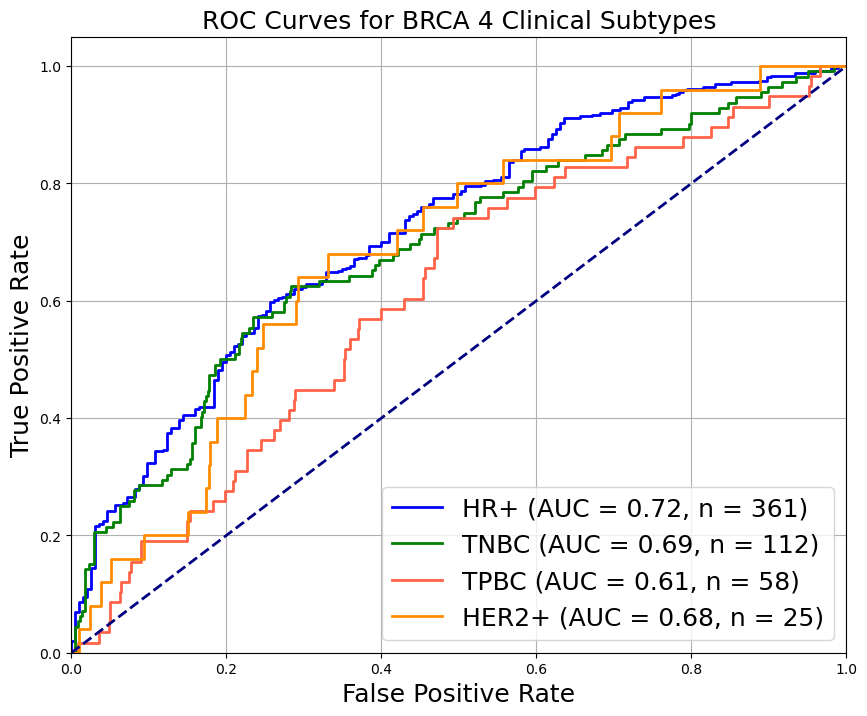

In [8]:
plot_combined_roc_curves(
    combined_results_df,
    subtypes_3,
    'ROC Curves for BRCA 3 Clinical Subtypes',
    'roc_3_subtypes.png'
)

plot_combined_roc_curves(
    combined_results_df,
    subtypes_4,
    'ROC Curves for BRCA 4 Clinical Subtypes',
    'roc_4_subtypes.png'
)

